В цьому домашньому завданні ми проведемо додаткові експерименти для рішення задачі бінарної класифікації і створимо ваш новий submission на змагання на Kaggle.

-----------


**Завдання 0**. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle)  Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").


**Завдання 1**. **Збираємо весь код з попереднього ДЗ в одному місці.** В лекційному ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb` ми познайомились з поняттям пайплайнів, а також я показала, як компактно виглядає рішення МЛ задачі, якщо ми зберемо весь код разом.

Оскільки ми далі будемо робити експерименти, які включають ті самі етапи попередньої обробки, але інше моделювання - буде зручно мати весь код компактно і під рукою. Тому зараз ми займемось збором коду до купи :) Після цього завдання для подальших експериментів ви можете перенести частини розвʼязку взагалі в окремий `.py` файл, аби було зручно імпортувати функції.

Зі свого рішення в попередньому домашньому завданні (`Логістична регресія з scikit learn.ipynb`) зберіть усі кроки розвʼязку задачі разом з використанням `sklearn.Pipeline` за прикладом з лекції.

Ваш код нижче має містити
1. Читання даних з файлу (поза пайплайном).
2. Розбиття на тренувальний і валідаційний набори, де валідаційний містить 20% даних (поза пайплайном).
3. Виділення категоріальних і числових колонок (поза пайплайном).
4. Підготовку категоріальних і числових колонок (частина пайплайну). В прикладі в лекції ми оформлювали обробку числових і категоріальних колонок в окремі трансформери `numeric_transformer`, `categorical_cols`. Рекоемндую зробити саме так, так потім зручніше вносити зміни :)
5. Тренування лог регресії (частина пайплайну).
6. Запуск пайплайну на тренування на трен. даних (поза пайплайном).
7. Запуск пайплайну на передбачення на трен і вал. даних і вимір метрик якості ROC-AUC + вивдення Confusion Matrix (поза пайплайном).
8. Збереження моделі в формат joblib (поза пайплайном).

Ви це все вже зробили в попереднтьому ДЗ! Тож, тут просто заадча все зібрати разом.

Нижче я додала підказки, що покроково ви маєте зробити. Якщо ви почуваєтесь впевнено, можете видалити ці підказки і реалізувати все самостійно, або ж - просто заповнити пропуски.

Завдання оцінюється в 10 балів. Головний результат - аби код в фіналі був робочий. Бо за не робочий нам гроші ніхто не заплатить :)

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import roc_curve, auc, confusion_matrix, mean_squared_error, root_mean_squared_error

import warnings
warnings.filterwarnings("ignore")

Area under ROC score on Train dataset: 0.88%


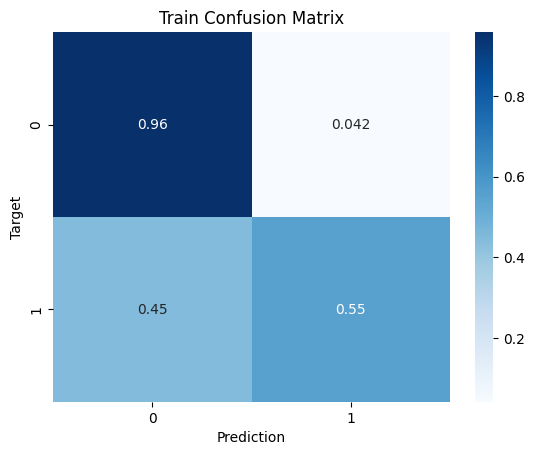

Area under ROC score on Validation dataset: 0.86%


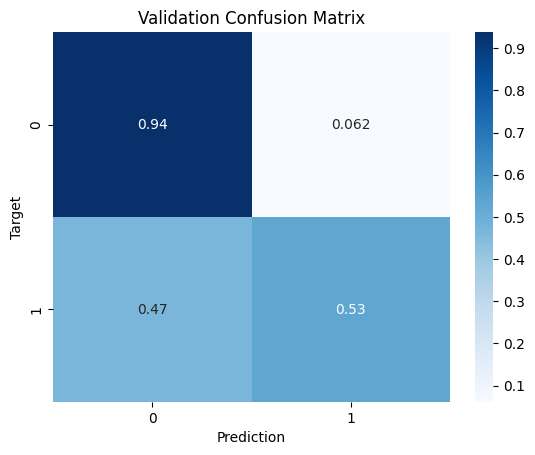

['log_reg_model_pipeline.joblib']

In [93]:
raw_df = pd.read_csv('train.csv', index_col=0)

# Створюємо трен. і вал. набори
input_cols = list(raw_df.columns)[1:-1]
target_col = 'Exited'
X = raw_df[input_cols].copy()
y = raw_df[target_col].copy()
train_inputs, val_inputs, train_targets, val_targets = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)

# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes(include='object').columns.tolist()

numeric_cols = [item for item in numeric_cols if item not in ['id', 'CustomerId']]
categorical_cols = [item for item in categorical_cols if item != 'Surname']

# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear'))
])

# Тренуємо пайплайн
model_pipeline.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(param_model_pipeline, inputs, targets, name=''):
    preds = param_model_pipeline.predict(inputs)
    y_pred_proba = param_model_pipeline.predict_proba(inputs)[:, 1]
    # Compute ROC curve
    fpr, tpr, thresholds = roc_curve(targets, y_pred_proba)
    # Compute AUROC
    roc_auc = auc(fpr, tpr)
    print(f"Area under ROC score on {name} dataset: {roc_auc:.2f}%")
    cf = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(cf, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline, train_inputs, train_targets, 'Train')
val_preds = predict_and_plot(model_pipeline, val_inputs, val_targets, 'Validation')

# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline, 'log_reg_model_pipeline.joblib')



**Завдання 2**. Такс, у нас з вами є вже готовий пайплайн. Давайте проведемо нові експерименти.

  Додайте в попередню обробку числових колонок генерацію polinomal features до степені 2 включно. Для цього створіть новий препроцесор і створіть новий пайплайн.

  Запустіть пайплайн на тренування і виведіть метрики для тренувального і валідаційного набору. Напишіть, як вам модель? Чи спостерігається в цій моделі overfit чи underfit? Чи ця модель добре генералізує?

Area under ROC score on Train dataset: 0.93%


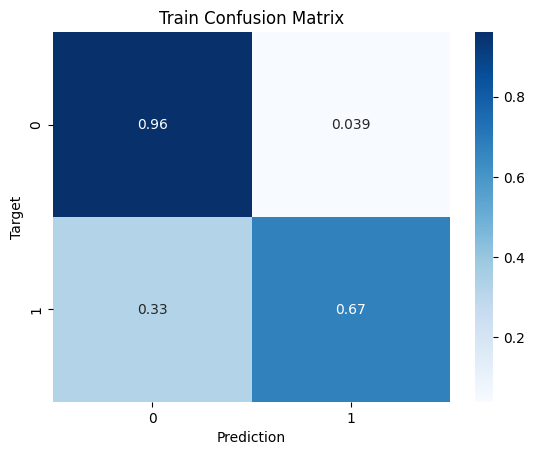

Area under ROC score on Validation dataset: 0.91%


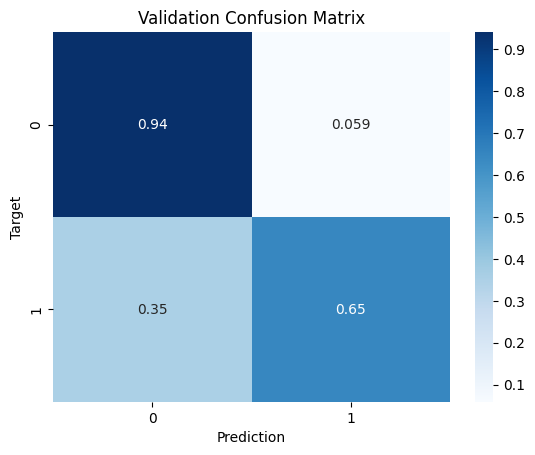


Спостеження:
З Polynomial Features (degree=2): перформанс моделі дещо покращився як на навчальному, так і на валідаційному наборах порівняно з базовою логістичною моделлю. Показники ROC-AUC збільшилися для обох, що вказує на те, що модель знаходить складніші взаємозв'язки в даних.
На цьому етапі не бачу суттєвого undefit чи overfit. Модель добре узагальнює.


In [94]:
numeric_transformer_poly_degree_2 = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler())
])

preprocessor_poly_2 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly_degree_2, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Стоврюємо новий пайплайн, який спочатку запускає препроцесинг з попередньою обробкою числових колонок
# генерацію polinomal features до степені 2 включно, потім тренуємо модель
model_pipeline_poly_degree_2 = Pipeline(steps=[
    ('preprocessor', preprocessor_poly_2),
    ('classifier', LogisticRegression(solver='liblinear', max_iter=1000))
])

# Тренуємо пайплайн
model_pipeline_poly_degree_2.fit(train_inputs, train_targets)


# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline_poly_degree_2, train_inputs, train_targets, 'Train')
val_preds = predict_and_plot(model_pipeline_poly_degree_2, val_inputs, val_targets, 'Validation')

print("\nСпостеження:")
print("З Polynomial Features (degree=2): перформанс моделі дещо покращився як на навчальному, так і на валідаційному наборах порівняно з базовою логістичною моделлю. Показники ROC-AUC збільшилися для обох, що вказує на те, що модель знаходить складніші взаємозв'язки в даних.")
print("На цьому етапі не бачу суттєвого undefit чи overfit. Модель добре узагальнює.")


**Завдання 3**. Тепер давайте створимо ще новий пайплайн, тільки тепер поліноміальні ознаки згенеруємо до степені 4. Зробіть висновок про якість моделі. Якщо вам подобається резульат якоїсь з моделей в цьому ДЗ - рекомендую зробити submission в змаганні.

Area under ROC score on Train dataset: 0.94%


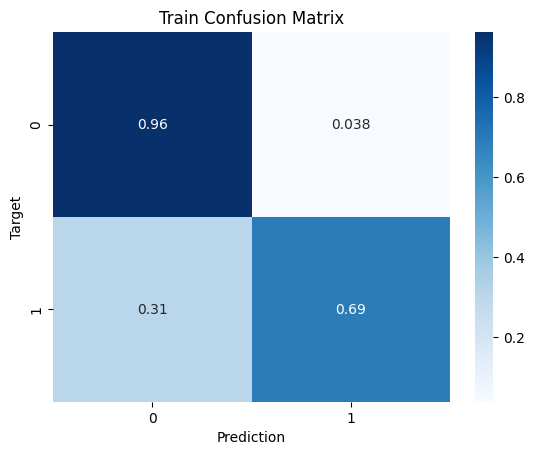

Area under ROC score on Validation dataset: 0.92%


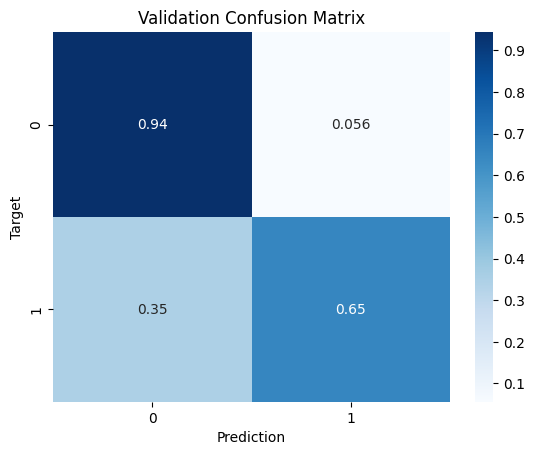


Conclusion:
З Polynomial Features (degree=4): якість моделі на навчальному і валідаційному наборах ще більше покращилася.


In [95]:
numeric_transformer_poly_degree_4 = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=4, include_bias=False)),
    ('scaler', StandardScaler())
])

preprocessor_poly_4 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly_degree_4, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Стоврюємо новий пайплайн, який спочатку запускає препроцесинг з попередньою обробкою числових колонок
# генерацію polinomal features до степені 4 включно, потім тренуємо модель
model_pipeline_poly_degree_4 = Pipeline(steps=[
    ('preprocessor', preprocessor_poly_4),
    ('classifier', LogisticRegression(solver='liblinear', max_iter=1000))
])

# Тренуємо пайплайн
model_pipeline_poly_degree_4.fit(train_inputs, train_targets)


# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline_poly_degree_4, train_inputs, train_targets, 'Train')
val_preds = predict_and_plot(model_pipeline_poly_degree_4, val_inputs, val_targets, 'Validation')

print("\nConclusion:")
print("З Polynomial Features (degree=4): якість моделі на навчальному і валідаційному наборах ще більше покращилася.")

In [96]:
test_raw_df = pd.read_csv('test.csv')

test_raw_df['Exited'] = model_pipeline_poly_degree_2.predict_proba(test_raw_df)[:, 1]
submission_df = pd.read_csv('sample_submission.csv')
submission_df['Exited'] = test_raw_df['Exited']
submission_df.to_csv('submission_log_reg_poly_2.csv', index=False)

test_raw_df['Exited'] = model_pipeline_poly_degree_4.predict_proba(test_raw_df)[:, 1]
submission_df['Exited'] = test_raw_df['Exited']
submission_df.to_csv('submission_log_reg_poly_4.csv', index=False)

**Завдання 4. Перенавчання і регуляризація**.

  Скачайте набір даних `regression_data.csv`. Звичайте набір даних з `regression_data.csv`, розбийте на train і test (в тест 20%) і натренуйте модель лінійної регресії з масштабуванням числових ознак і поліноміальними ознаками до степені **5 включно**.

  Виміряйте якість прогностичної моделі і зробіть висновок, чи модель хороша, чи вона добре генералізує?


In [108]:
regression_df = pd.read_csv('regression_data.csv')

target_col_name = "target"
X = regression_df.drop([target_col_name],axis=1)
y = regression_df[[target_col_name]]

# Розбивка на тренувальні та тестувальні. дані
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [109]:
def train_lin_vs_poly_reg_and_plot(X_train, X_test, y_train, y_test, degree):
  # Звичайна лінійна регресія
  lin_reg = LinearRegression()
  lin_reg.fit(X_train, y_train)
  y_pred_train_lin = lin_reg.predict(X_train)
  y_pred_test_lin = lin_reg.predict(X_test)

  # масштабування числових даних
  scaler = StandardScaler()
  scaler.fit(X_train)
  X_train = scaler.transform(X_train)
  X_test = scaler.transform(X_test)

  # Поліноміальна регресія
  poly_features = PolynomialFeatures(degree=degree)
  X_train_poly = poly_features.fit_transform(X_train)
  X_test_poly = poly_features.transform(X_test)

  print(f'В оригіналній матриці Х {X.shape[1]} ознак.')
  print(f'В матриці Х з поліноміальними ознаками {X_train_poly.shape[1]} ознак.\n')

  poly_reg = LinearRegression()
  poly_reg.fit(X_train_poly, y_train)
  y_pred_train_poly = poly_reg.predict(X_train_poly)
  y_pred_test_poly = poly_reg.predict(X_test_poly)

  # Оцінка моделей

  rmse_lin_train = mean_squared_error(y_train, y_pred_train_lin)
  rmse_poly_train = mean_squared_error(y_train, y_pred_train_poly)

  rmse_lin_test = mean_squared_error(y_test, y_pred_test_lin)
  rmse_poly_test = mean_squared_error(y_test, y_pred_test_poly)


  print(f"Train RMSE for Linear Regression: {np.sqrt(rmse_lin_train):.3f}")
  print(f"Test RMSE for Linear Regression: {np.sqrt(rmse_lin_test):.3f}\n")

  print(f"Train RMSE for Polynomial Regression (degree {degree}): {np.sqrt(rmse_poly_train):.3f}")
  print(f"Test RMSE for Polynomial Regression (degree {degree}): {np.sqrt(rmse_poly_test):.3f}")

In [110]:
degree = 5
train_lin_vs_poly_reg_and_plot(X_train, X_test, y_train, y_test, degree)

В оригіналній матриці Х 5 ознак.
В матриці Х з поліноміальними ознаками 252 ознак.

Train RMSE for Linear Regression: 1.066
Test RMSE for Linear Regression: 0.883

Train RMSE for Polynomial Regression (degree 5): 0.000
Test RMSE for Polynomial Regression (degree 5): 35.628


### Спостереження:

*   Модель polynomial regression з degree=5 показує дуже високий  overfitting.
*  'RMSE на тренувіальних даних для Polynomial Regression (degree 5)' was 0.000,  що означає ідеальну модель, що ідеально визначає кожен тарегт без помилок.
*   Але RMSE на тестових даних для Polynomial Regression (degree 5) є 35.628, значно вища помилка, ніж на тренувальних даних. Отже, мождель завчила всі викиди, шуми у навчальних даних, але не вивчила взаємозвязки, і не можу добре узагальнювати нові дані, яких не бачила.
*   В даному випадку бащова ліінйна регресія набагато краще буде прогнозувати дані на тестовому наборі.

**Завдання 5**. Натренуйте моделі Lasso(), Ridge(), ElasaticNet() на цих даних (з поліном ознаками до степені 20 включно), порівняйте якість з тою, яка була отримана з лінійною регресією. Яка модель найкраще генералізує і чому на ваш погляд (можливо треба буде для відповіді зробити додатковий аналіз ознак)?

In [111]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_metrics = root_mean_squared_error(y_train, y_train_pred)
    test_metrics = root_mean_squared_error(y_test, y_test_pred)

    return dict(train=train_metrics, test=test_metrics)

In [112]:
models = [
    Lasso(),
    Ridge(),
    ElasticNet()
]

poly_features = PolynomialFeatures(degree=20)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

print(f'X_train:')
print(X_train.describe())
print('\n')

for model in models:
    model.fit(X_train_poly, y_train)
    eval_results  = evaluate_model(model, X_train_poly, y_train, X_test_poly, y_test)
    print(f'{str(model)}: {eval_results}\n')

X_train:
        feature_1   feature_2   feature_3   feature_4   feature_5
count  103.000000  103.000000  103.000000  103.000000  103.000000
mean    -0.029182    0.056721    0.122185   -0.128463    0.054544
std      0.925083    1.102164    0.969330    0.888132    1.008238
min     -3.241267   -2.619745   -1.913280   -2.211135   -2.301921
25%     -0.657976   -0.633910   -0.541705   -0.769480   -0.709699
50%     -0.013497   -0.074446    0.232254   -0.012247   -0.018513
75%      0.521795    0.817535    0.670831    0.408416    0.672042
max      2.122156    3.852731    3.078881    2.190456    2.075401


Lasso(): {'train': 2.313505449570354, 'test': 68.31879121877043}

Ridge(): {'train': 32.58206767922066, 'test': 9034.945944005218}

ElasticNet(): {'train': 10.159852342199374, 'test': 1526.8209205681153}



### Спостереження:

Якщо порівнбвати моделі, то попередня лінійна модель з Polynomial Regression (degree 5) краща, ніж будь яка з моделей з завдання 5, тому що rmse для них надзвичайно високі на тестових даних (хоча і на тренувальних теж не є малі помилки). Але загалом для цих даних краще підійде звтчайна LinearRegression без поліноміальних ознак.